In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## # Reasons why I chose this dataset for a Decision Tree Classifier because:

*Binary Classification: The target variable is categorical (0 or 1).                                                                          
Numerical Features: No need for scaling or preprocessing.                                                                                                                             
No Missing Values: Clean dataset for training.                                                                                                           
Balanced Classes: Avoids bias in predictions.                                                                                                                                                                                      
Handles Non-Linear Patterns: Decision trees capture complex relationships.                                                                                                            
Interpretability: Easy to understand decision-making.                                                                                                         
Fast & Efficient: Small dataset, quick training.*

In [2]:
#1. Loading The Dataset

# Command is used for loading/ reading the Data
data = pd.read_csv('Bank Note Authentication.csv')
data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


**This code reads the "Bank Note Authentication.csv" file into a DataFrame called data and displays the first 5 rows of the dataset to give a quick look at its structure and values.*

In [3]:
#2. Uses Is Null code to find the Missing Values in the Dataset

print("Missing Values in Each Column:")
print(data.isnull().sum())

Missing Values in Each Column:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


**This code checks for missing values in each column of the dataset and prints the count for each column. If all counts are zero, there are no missing values.*

In [4]:
#3. Uses the code to get Summary Statistics

print("\nSummary Statistics:")
print(data.describe())


Summary Statistics:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


**This code shows summary stats for the numbers in your data, including:
Count: Non-missing values.
Mean: Average value.
Std: How spread out values are.
Min, 25%, 50%, 75%, Max: Percentiles for value distribution.
This helps understand the range, spread, and center of the data.*

In [5]:
#4. Uses the code to  get Skewness and Kurtosis Check

skewness = data.skew()
kurtosis = data.kurt()

print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)

Skewness:
 variance   -0.149388
skewness   -0.394103
curtosis    1.088569
entropy    -1.022243
class       0.223191
dtype: float64

Kurtosis:
 variance   -0.751581
skewness   -0.437212
curtosis    1.270476
entropy     0.497496
class      -1.953035
dtype: float64


**Skewness: Measures how asymmetrical the data is — positive means a right skew, negative means a left skew.
Kurtosis: Measures how peaked or flat the data is — higher values mean sharper peaks, lower mean flatter*

In [6]:
#5. Uses the code for Outlier Detection using IQR Method

outliers = {}
for col in data.columns[:-1]:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers[col] = data[(data[col] < Q1 - 1.5 * IQR) | (data[col] > Q3 + 1.5 * IQR)].shape[0]

print("\nOutliers detected per feature:")
print(outliers)


Outliers detected per feature:
{'variance': 0, 'skewness': 0, 'curtosis': 59, 'entropy': 33}


**data.columns[:-1] picks all columns except the last one (assumed to be 'class'). The -1 means "leave out the last column."
The code then makes box plots for each feature to find outliers.
This way, we only look at features and ignore the target column*

**Detects outliers: Uses the IQR (Interquartile Range) method to count outliers for each feature.
Stores results: Saves the count of outliers in the outliers dictionary for each column.
Prints results: Displays how many outliers each feature has*

In [7]:
#6. Uses the code to Correlation Matrix

correlation = data.corr()
print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
          variance  skewness  curtosis   entropy     class
variance  1.000000  0.264026 -0.380850  0.276817 -0.724843
skewness  0.264026  1.000000 -0.786895 -0.526321 -0.444688
curtosis -0.380850 -0.786895  1.000000  0.318841  0.155883
entropy   0.276817 -0.526321  0.318841  1.000000 -0.023424
class    -0.724843 -0.444688  0.155883 -0.023424  1.000000


**Calculates correlation: Finds how strongly features are related to each other (ranges from -1 to 1).
Prints matrix: Displays a table showing correlation values between every pair of features.*

In [8]:
#7. Variance Inflation Factor (VIF) for Multicollinearity Check

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data.iloc[:, :-1]  # Exclude the target column
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVariance Inflation Factor (VIF):")
print(vif_data)


Variance Inflation Factor (VIF):
    Feature       VIF
0  variance  1.353257
1  skewness  3.359866
2  curtosis  1.903403
3   entropy  2.169949


**Calculates VIF: Measures if features are highly correlated with each other (multicollinearity); VIF > 5 suggests a problem.
Creates a table: Shows VIF values for each feature to help decide if any should be removed.*


Class Distribution:
class
0    762
1    610
Name: count, dtype: int64


<ipython-input-9-9716ac6cff74>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=data, palette='pastel')


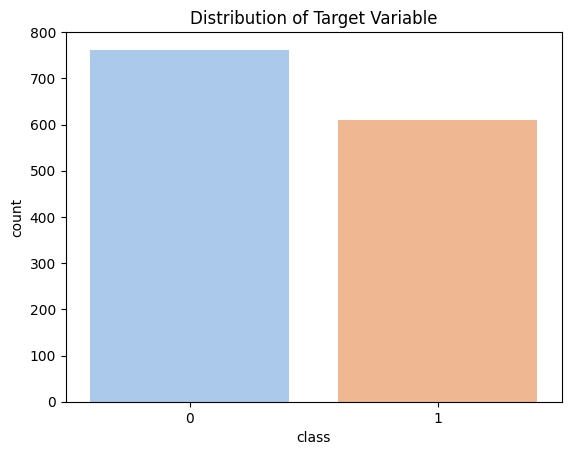

In [9]:
#8. Target Variable Analysis

print("\nClass Distribution:")
print(data['class'].value_counts())

sns.countplot(x='class', data=data, palette='pastel')
plt.title('Distribution of Target Variable')
plt.show()

**Prints class distribution: Shows how many real (0) and fake (1) notes are in the dataset.
Creates a count plot: Uses bars to visualize the number of samples for each class (real vs. fake).*
Palette is used for Color Schemes

**Class distribution shows how many data points belong to each category or class (like real (0) and fake (1) notes) in the dataset. 📊**

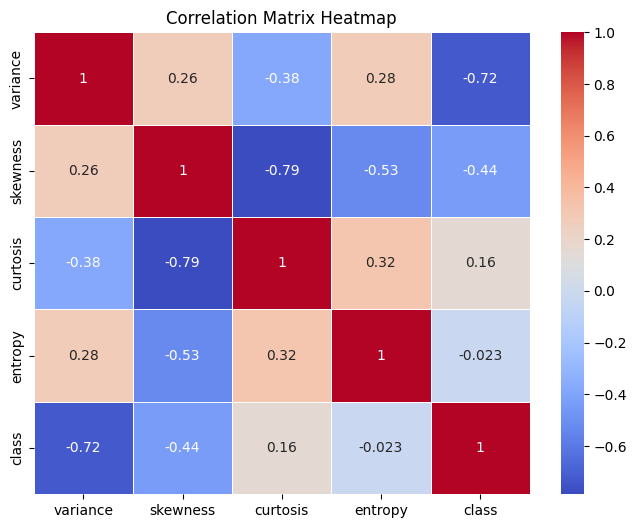

In [10]:
#9. Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

**Creates a heatmap: Visualizes the correlation matrix with colors to show how strongly features are related.
Displays values: The annot=True option prints correlation numbers inside the heatmap for clarity.*
CMap is used for Color Mapping

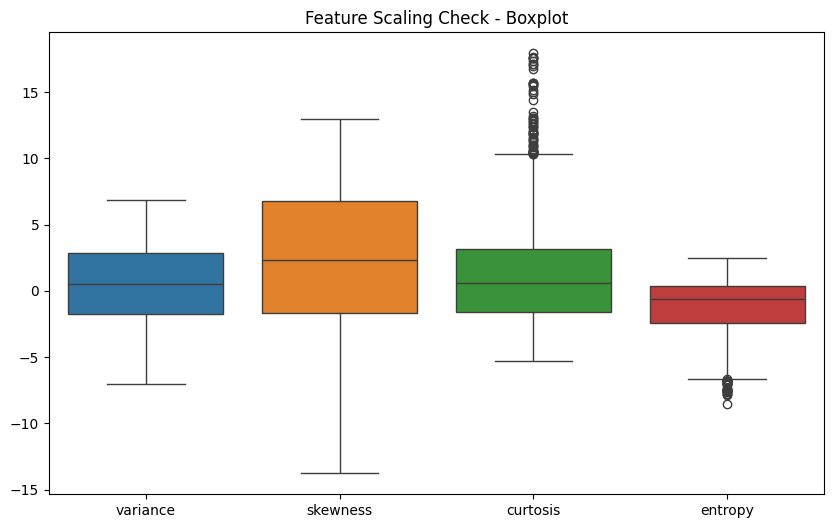

In [11]:
#10. Feature Scaling Check as BoxPlot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=data.drop(columns=['class']))
plt.title("Feature Scaling Check - Boxplot")
plt.show()


**Creates a box plot: Shows how each feature is spread and scaled (ranges and outliers).
Excludes target column: Uses only feature columns to check if they need scaling for better model performance.*

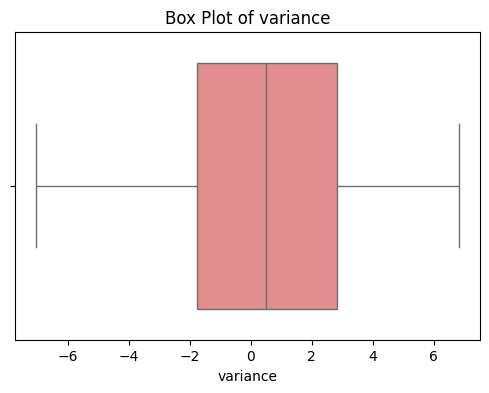

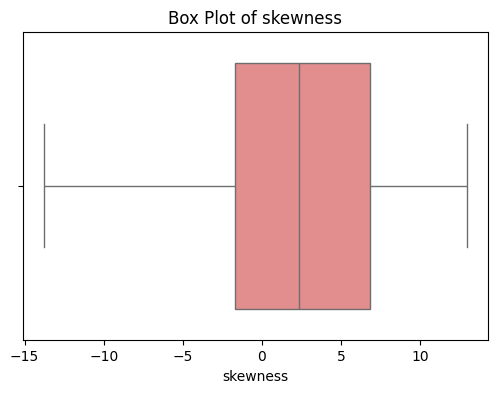

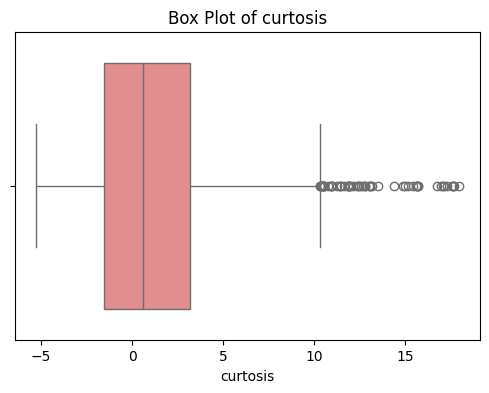

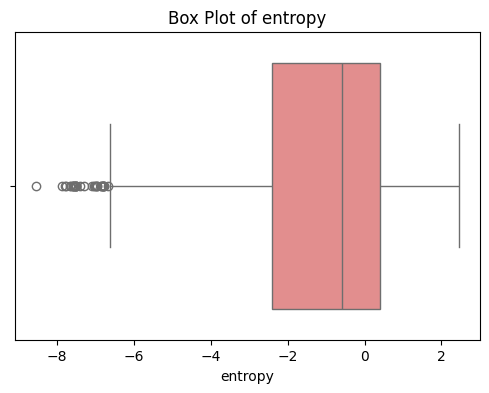

In [12]:
#11. Box Plots for Outlier Detection

features = data.columns[:-1]  # Define features (all columns except 'class')
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[feature], color='lightcoral')
    plt.title(f'Box Plot of {feature}')
    plt.show()

**Defines features: Picks all columns except the last one (class) to focus only on input features.
Creates box plots: Displays each feature's spread and outliers using box plots with a light coral color.*

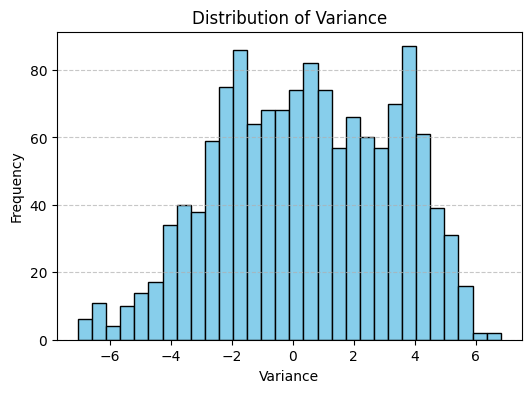

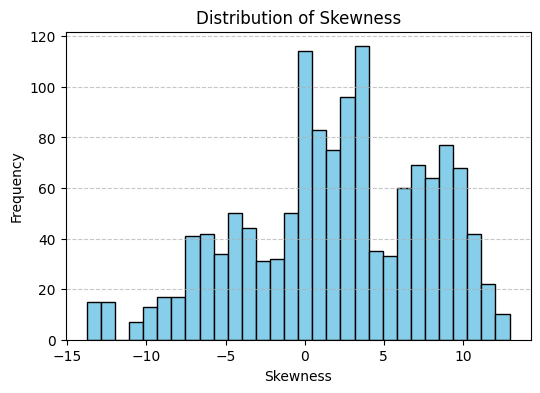

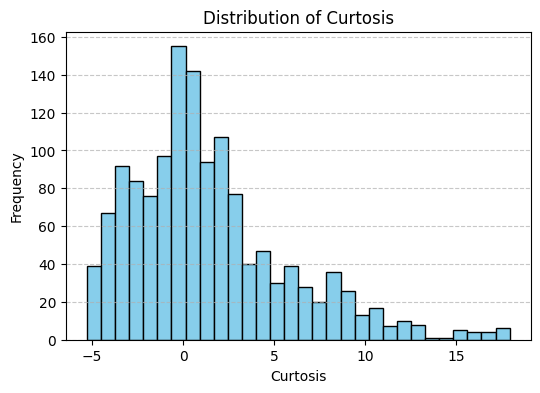

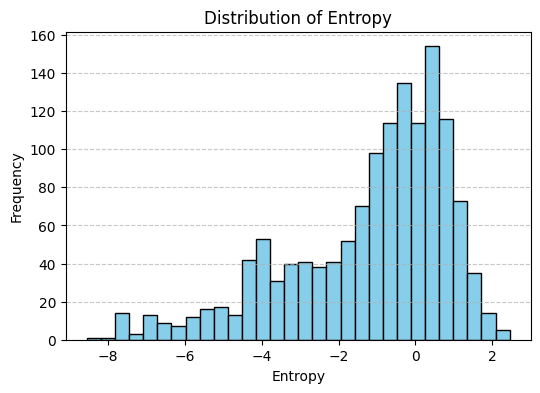

In [13]:
#12. Distribution of Variance, Skewness, Kurtosis, Entropy

features = ['variance', 'skewness', 'curtosis', 'entropy']

# Plot histograms for each feature
for feature in features:
    plt.figure(figsize=(6, 4))
    plt.hist(data[feature], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

**Creates histograms: Plots bar-like graphs to show how variance, skewness, kurtosis, and entropy values are spread.
Helps understand shape: Makes it easy to spot if data is normal, skewed, or has outliers for each feature.*

<ipython-input-14-b9260d96eb60>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y=col, data=data, palette='coolwarm')


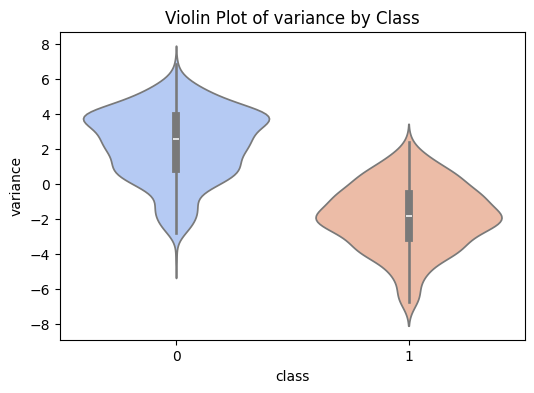

<ipython-input-14-b9260d96eb60>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y=col, data=data, palette='coolwarm')


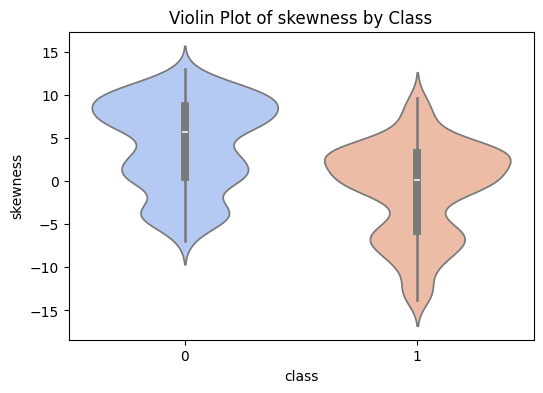

<ipython-input-14-b9260d96eb60>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y=col, data=data, palette='coolwarm')


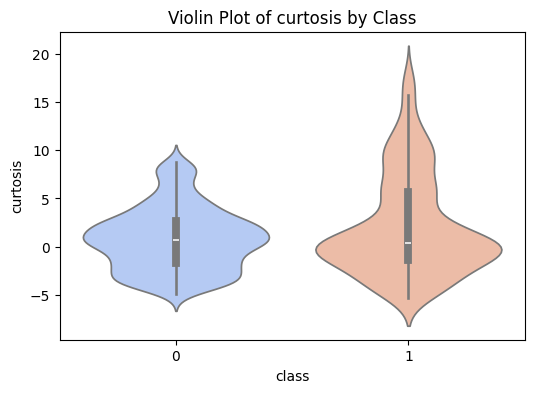

<ipython-input-14-b9260d96eb60>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y=col, data=data, palette='coolwarm')


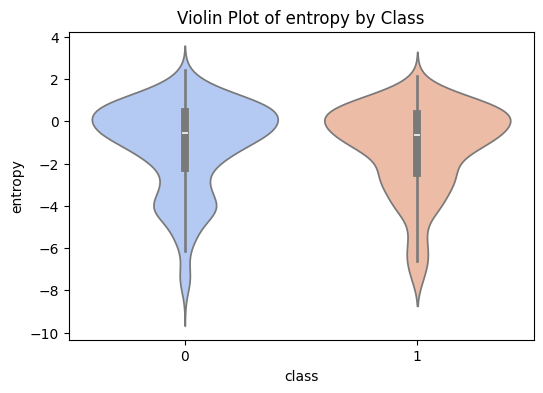

In [14]:
#13. Class Distribution in Features (Violin Plots)

for col in data.columns[:-1]:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x='class', y=col, data=data, palette='coolwarm')
    plt.title(f'Violin Plot of {col} by Class')
    plt.show()

**Creates violin plots: Shows the distribution and density of each feature for both real (0) and fake (1) classes.
Compares classes: Helps see how well features separate the two classes by showing overlap or gaps.*

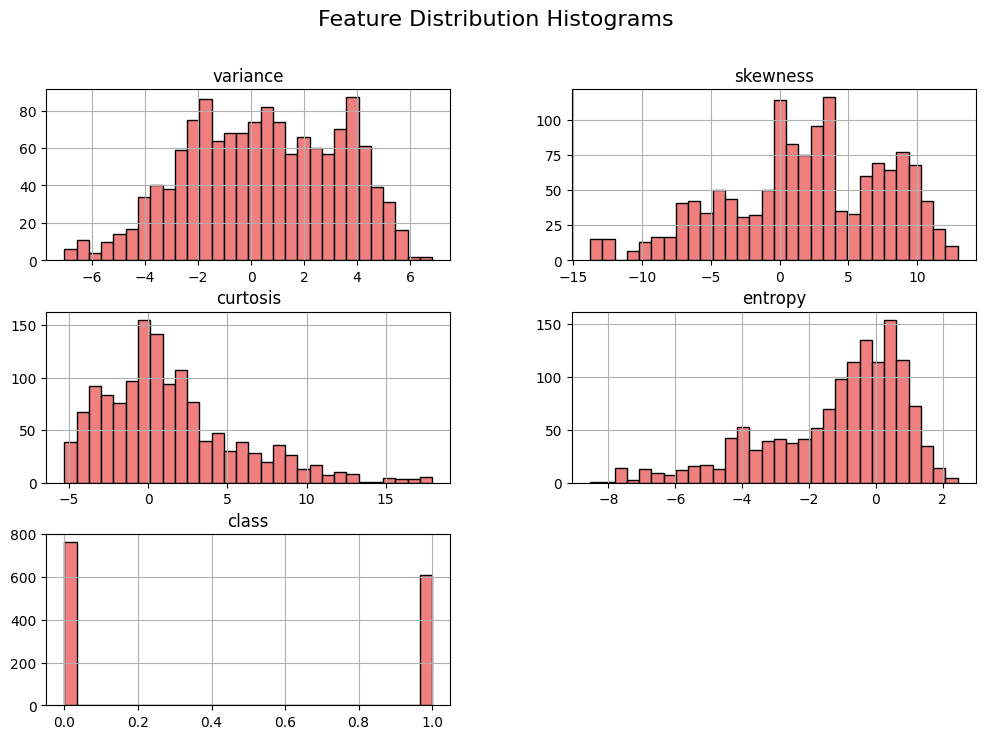

In [15]:
#14. Feature Distribution (Histograms for All Features)

data.hist(bins=30, figsize=(12, 8), color='lightcoral', edgecolor='black')
plt.suptitle('Feature Distribution Histograms', fontsize=16)
plt.show()

**Creates histograms for all features: Plots bar-like graphs to show how each feature's values are spread.
Helps spot patterns: Makes it easy to see if features are normal, skewed, or have outliers at a glance.*

figsize=(12, 8) means Size of figure in inches(width,height.

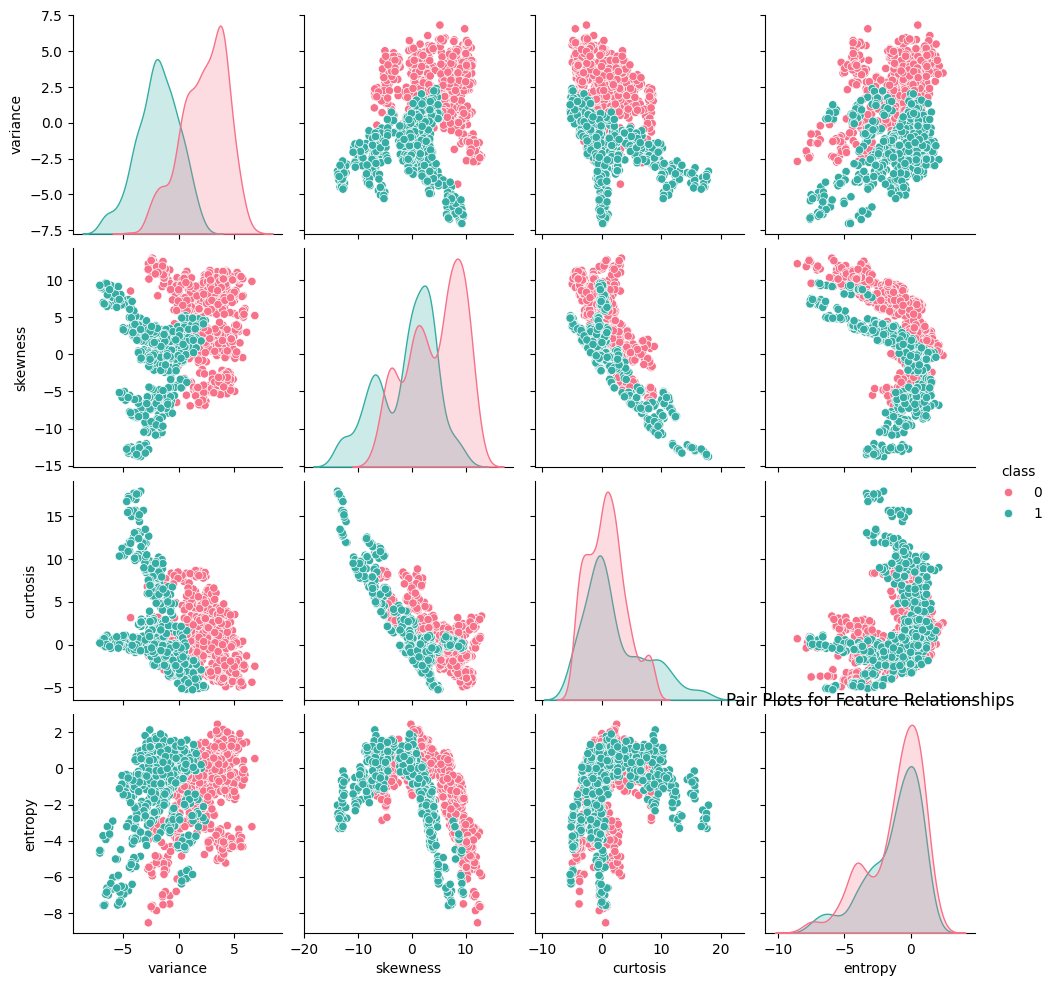

In [16]:
#15. Pair Plot to Visualize Feature Relationships

sns.pairplot(data, hue='class', palette='husl')
plt.title('Pair Plots for Feature Relationships')
plt.show()

**Creates pair plots: Shows scatter plots between every pair of features to spot patterns.
Colors by class: Uses different colors for real and fake notes based on the 'class' column.*

**A scatter plot shows dots representing data points on a graph to visualize the relationship between two features. 📊**

**Creates pair plots: Shows scatter plots for every pair of features to visualize relationships and patterns.
Uses color for classes: hue='class' colors points based on real (0) and fake (1) notes to see how well features separate the classes.*
hue in this classifies the two types used here Two diff dat(pink and blue)

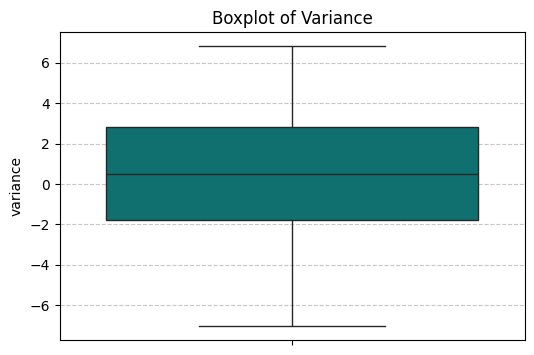

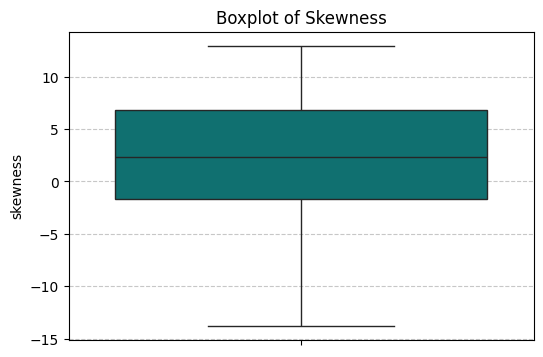

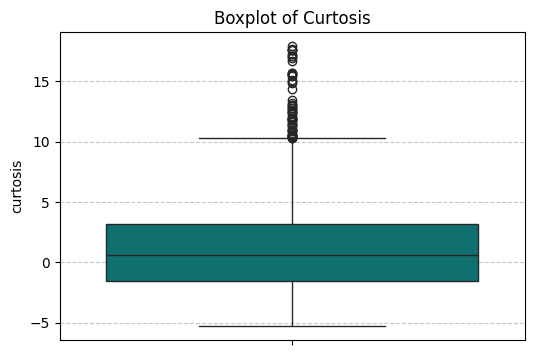

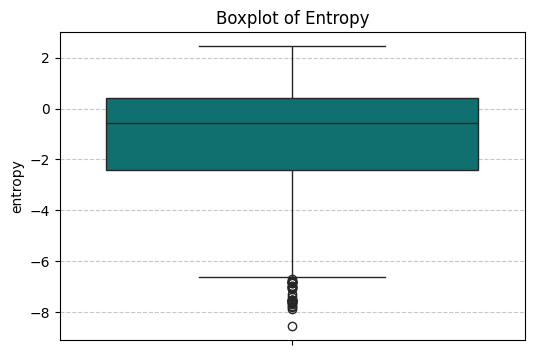

In [17]:
#16. Feature Distribution (Boxplots for Outlier Detection)

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=data[feature], color='teal')
    plt.title(f'Boxplot of {feature.capitalize()}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

**Creates box plots: Visualizes each feature's spread and outliers with a teal color.
Helps detect outliers: Makes it easy to spot extreme values beyond the whiskers of the box.*

In [18]:
#17. Import necessary libraries for Decision Tree.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separate features (X) and target (y)
X = data.drop('class', axis=1)
y = data['class']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Splits the data: 80% for training, 20% for testing.
# Creates a decision tree model: Using default settings.
# Trains the model: On the training set.
# Evaluates the model: Using accuracy, a classification report, and a confusion matrix.

Accuracy: 0.9818181818181818

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       148
           1       1.00      0.96      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275


Confusion Matrix:
 [[148   0]
 [  5 122]]



### 🏆 **Key Insights:**
- **Precision and Recall** are high for both classes, meaning this model is great at identifying both types of notes (authentic or not).  
- The confusion matrix shows only a few misclassifications (5 out of 275).  

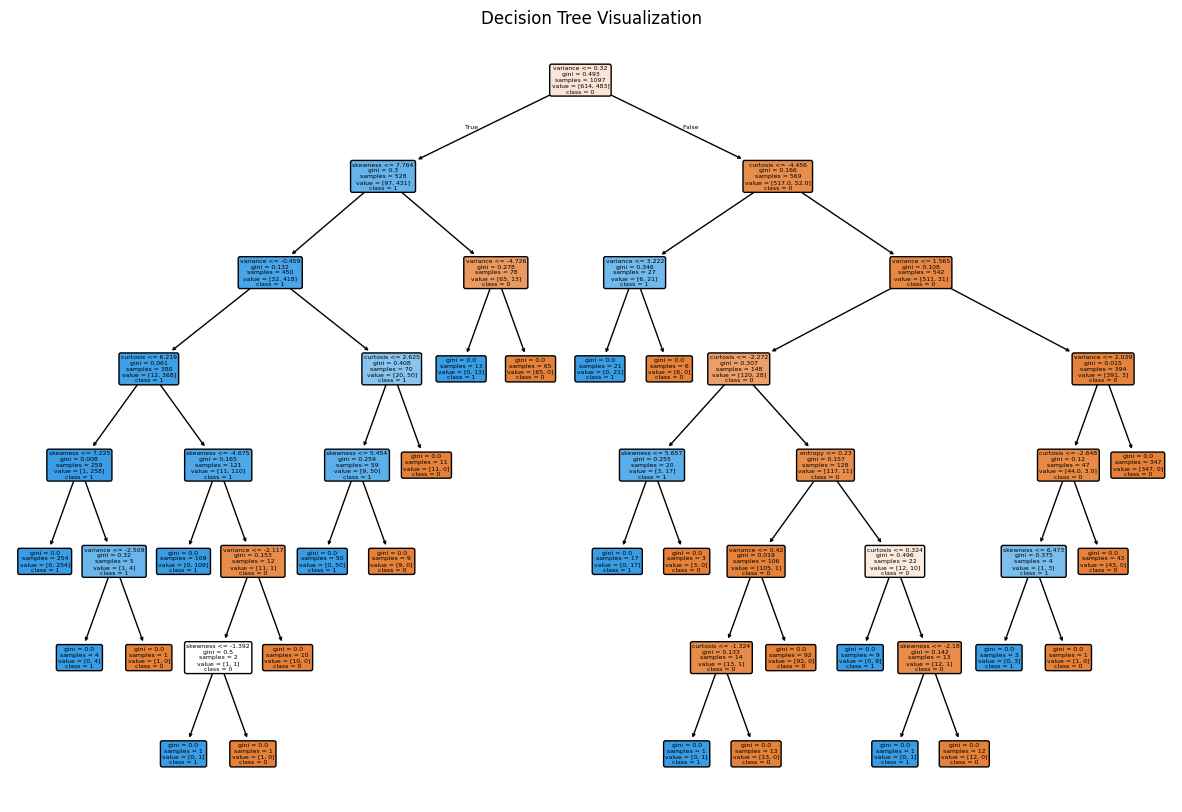

In [19]:
#18. Import necessary libraries for visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set up the plot size for better visibility
plt.figure(figsize=(15, 10))

# Plot the decision tree
plot_tree(model, feature_names=X.columns, class_names=['0', '1'], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()


#🎯 Big Picture: What Is This Decision Tree Doing?
This decision tree is helping us decide if a banknote is real (class 0) or fake (class 1) based on four features:

Variance
Skewness
Curtosis
Entropy
Think of it like a series of questions about these features that lead to a final decision.

#🛤️ How the Tree Works Step-by-Step:

*Start at the Top (Root Node): 🌱*

The very first question is about one of the features (let's say variance).
If the answer is Yes (go left) or No (go right), we move down a path.

*Follow the Branches: 🌿*

Each split (or branch) is a question about a feature, like:
"Is variance less than 0.5?"
"Is skewness greater than -2?"
Depending on the answer, we move to the next node.

*Reach the End (Leaf Nodes): 🍁*

At the bottom of the tree, we have leaf nodes. These are the final decisions:
Class 0: Real banknote.
Class 1: Fake banknote.

#🔍 What the Colors Mean:
Blue Boxes: Indicate one class (let’s say real notes).
Orange Boxes: Indicate the other class (fake notes).
The darker the shade, the more confident the model is about that decision.

#📊 What's Inside Each Box?
Each box has some information:

Gini: Measures how mixed the data is. Lower is better — means cleaner splits.
Samples: Number of data points at that point in the tree.
Value: How many data points belong to each class at that point.
Class: The final decision (0 or 1).

#🏆 Key Takeaway:
The tree is like a detective that asks questions about a banknote’s features one by one.
By following the branches based on answers, it reaches a confident decision about whether the note is real or fake.


Feature Importance from Random Forest:
variance    0.547055
skewness    0.237783
curtosis    0.155788
entropy     0.059374
dtype: float64


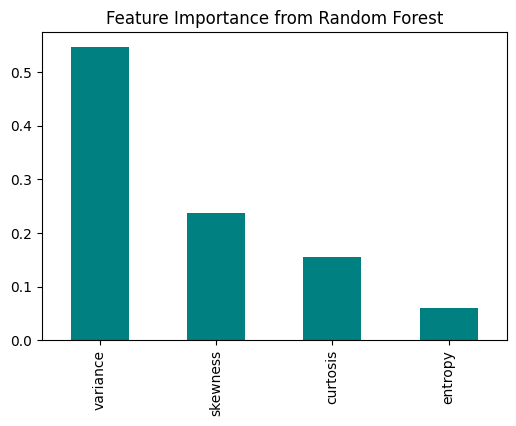

In [20]:
#19. Feature Importance using Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, data['class'])
feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nFeature Importance from Random Forest:")
print(feature_importances)

# Plot feature importance
plt.figure(figsize=(6, 4))
feature_importances.plot(kind='bar', color='teal')
plt.title('Feature Importance from Random Forest')
plt.show()

**Trains a Random Forest: Fits a Random Forest model to find which features are most important for predicting real or fake notes.
Shows feature importance: Displays and plots how much each feature contributes to the model's decisions using a bar chart.*

In [21]:
#20. Gini Index

from sklearn.tree import DecisionTreeClassifier

# Create and train the decision tree using Gini Index
tree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
tree_gini.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

**DecisionTreeClassifier(criterion='gini') trains a tree using the Gini Index to measure how pure or impure each split is.
Output: Creates a tree that splits data to minimize impurity, making it easier to separate classes effectively.*

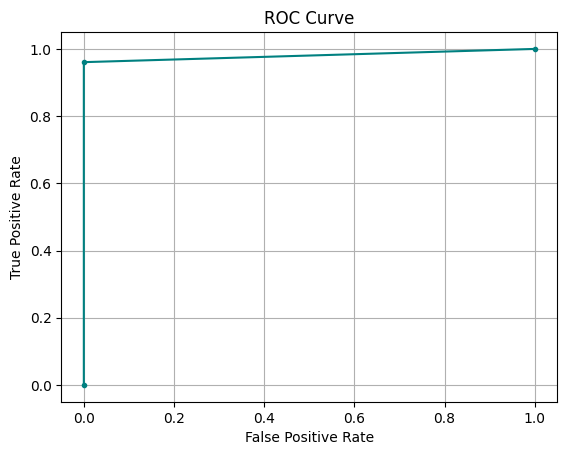

In [22]:
#21. ROC Curve for Classifier Performance

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, marker='.', color='teal')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()

**An ROC Curve plots the True Positive Rate vs. False Positive Rate to show how well a model distinguishes between classes. A curve closer to the top-left indicates a better model.
This ROC Curve shows a model with high performance since the curve is close to the top-left corner. The sharp rise suggests that the model has a high True Positive Rate with a low False Positive Rate, implying it can accurately distinguish between classes.*